Name:Mollika Deb
Email: mollika.m.deb@utu.fi
Student ID: 2514819

1

In [1]:
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt


In [2]:
# Load ECG–PPG dataset
df = pd.read_csv("ecg_ppg_clean.csv")   

ecg = df["ecg"].values
fs = 128 


In [3]:
def bandpass_filter(signal, fs, lowcut=5, highcut=15, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, signal)

# Apply band-pass filter
ecg_bandpassed = bandpass_filter(ecg, fs)


In [4]:
def derivative_filter(signal):
    # First-order derivative (difference)
    derivative = np.diff(signal)
    derivative = np.append(derivative, 0)  # keep same length
    return derivative

# Apply derivative filter
ecg_derivative = derivative_filter(ecg_bandpassed)


In [5]:
ecg_processed = ecg_derivative ** 2


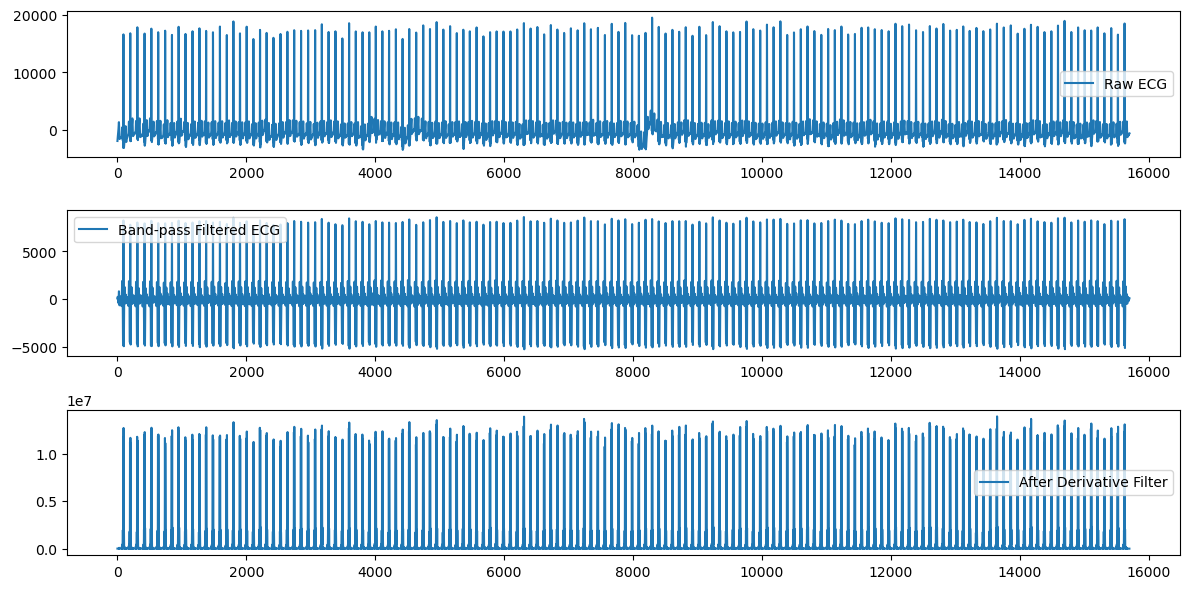

In [6]:
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1)
plt.plot(ecg, label="Raw ECG")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(ecg_bandpassed, label="Band-pass Filtered ECG")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(ecg_processed, label="After Derivative Filter")
plt.legend()

plt.tight_layout()
plt.show()


2.1

In [7]:
from scipy.signal import find_peaks

# Minimum distance between peaks (in samples)
# 0.4 s ≈ max 150 bpm (physiological limit)
min_distance = int(0.4 * fs)

# Detect peaks
peaks, properties = find_peaks(
    ecg_processed,
    distance=min_distance,
    height=np.mean(ecg_processed)
)

# Convert peak indices to time (seconds)
peak_times = peaks / fs


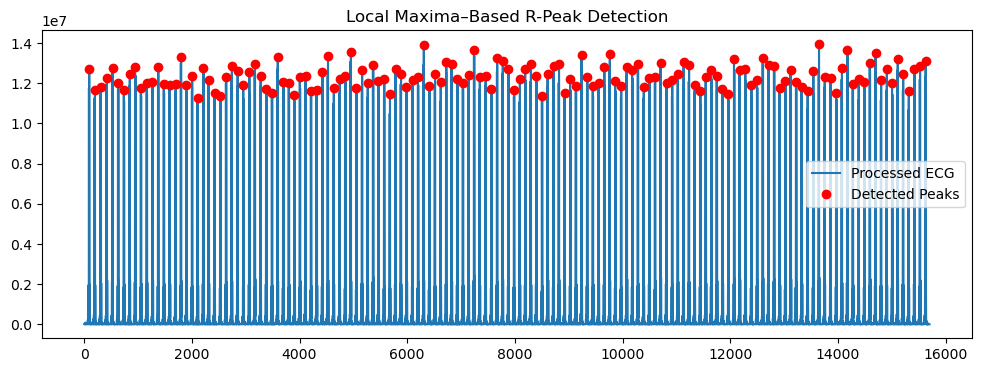

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(ecg_processed, label="Processed ECG")
plt.plot(peaks, ecg_processed[peaks], "ro", label="Detected Peaks")
plt.legend()
plt.title("Local Maxima–Based R-Peak Detection")
plt.show()


2.2
R-peaks were detected using a simple local maxima–based method applied to the preprocessed ECG signal. Peaks were identified as points that are higher than their neighboring samples and meet basic height and distance conditions. This straightforward approach allows reliable detection of one R-peak per heartbeat without using a complex detection algorithm.

3.1

In [9]:
import numpy as np

# Convert peak indices to time (seconds)
peak_times = peaks / fs

# RR intervals (seconds)
rr_intervals = np.diff(peak_times)

# Heart rate (bpm)
heart_rate = 60 / rr_intervals


In [10]:
# Physiological RR interval limits (seconds)
rr_min = 0.3   # corresponds to ~200 bpm
rr_max = 2.0   # corresponds to ~30 bpm

# Valid RR mask
valid_rr = (rr_intervals >= rr_min) & (rr_intervals <= rr_max)

# Filter RR intervals and HR
rr_intervals_clean = rr_intervals[valid_rr]
heart_rate_clean = heart_rate[valid_rr]

# Keep corresponding peak times (remove invalid beats)
peak_times_clean = peak_times[:-1][valid_rr]


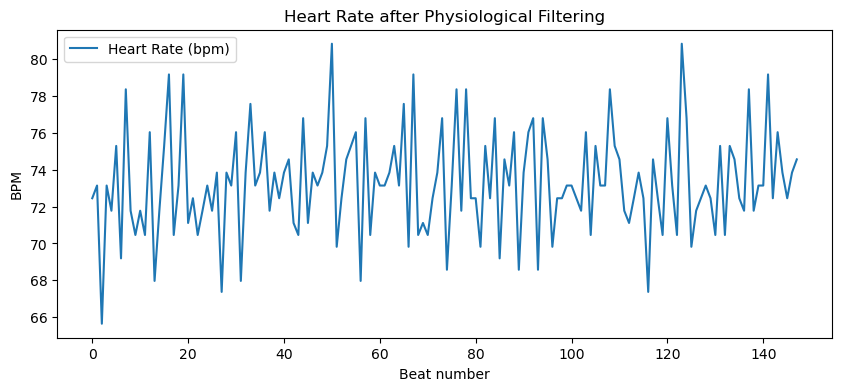

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(heart_rate_clean, label="Heart Rate (bpm)")
plt.xlabel("Beat number")
plt.ylabel("BPM")
plt.title("Heart Rate after Physiological Filtering")
plt.legend()
plt.show()


3.2
Heart rate was calculated from the RR intervals obtained from the detected R-peaks. RR intervals that were physiologically unrealistic were removed to eliminate false or missed detections. As a result, the heart rate signal remains within a realistic physiological range and shows smooth beat-to-beat variation.

4.1

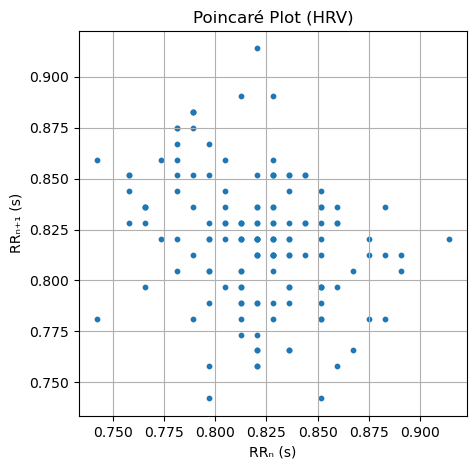

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Poincaré plot
rr_n = rr_intervals_clean[:-1]
rr_n1 = rr_intervals_clean[1:]

plt.figure(figsize=(5, 5))
plt.scatter(rr_n, rr_n1, s=10)
plt.xlabel("RRₙ (s)")
plt.ylabel("RRₙ₊₁ (s)")
plt.title("Poincaré Plot (HRV)")
plt.grid(True)
plt.show()


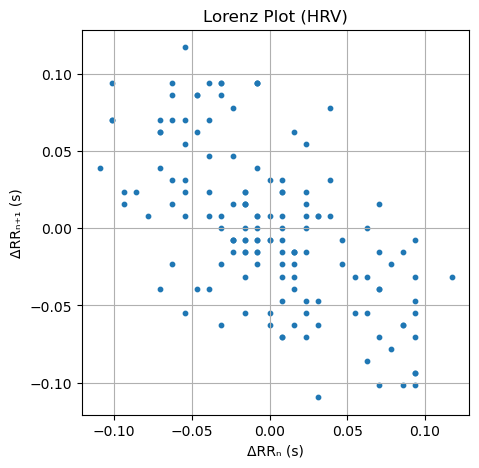

In [13]:
# First differences of RR intervals
drr = np.diff(rr_intervals_clean)

# Lorenz plot
plt.figure(figsize=(5, 5))
plt.scatter(drr[:-1], drr[1:], s=10)
plt.xlabel("ΔRRₙ (s)")
plt.ylabel("ΔRRₙ₊₁ (s)")
plt.title("Lorenz Plot (HRV)")
plt.grid(True)
plt.show()


4.2
Heart rate variability has been estimated using Poincaré and Lorenz plots based on the cleaned RR intervals. The Poincaré plot represents the relationship between consecutive RR intervals, and the Lorenz plot shows the relationship between successive RR interval differences. The distribution of points indicates normal beat-to-beat variability.

5.1

In [14]:
ppg = df["ppg_1_green"].values  # use any clean PPG channel


In [15]:
ppg_foot_indices = []

search_window = int(0.4 * fs)  # 400 ms window after ECG peak

for r_peak in peaks:
    start = r_peak
    end = min(r_peak + search_window, len(ppg))

    # Find PPG foot as minimum in the window
    foot_index = start + np.argmin(ppg[start:end])
    ppg_foot_indices.append(foot_index)

ppg_foot_indices = np.array(ppg_foot_indices)


In [16]:
# Convert indices to time
ecg_times = peaks / fs
ppg_times = ppg_foot_indices / fs

# Compute delays (seconds)
time_delays = ppg_times - ecg_times

# Average delay
average_delay = np.mean(time_delays)

print(f"Average ECG–PPG delay: {average_delay:.3f} s")


Average ECG–PPG delay: 0.147 s


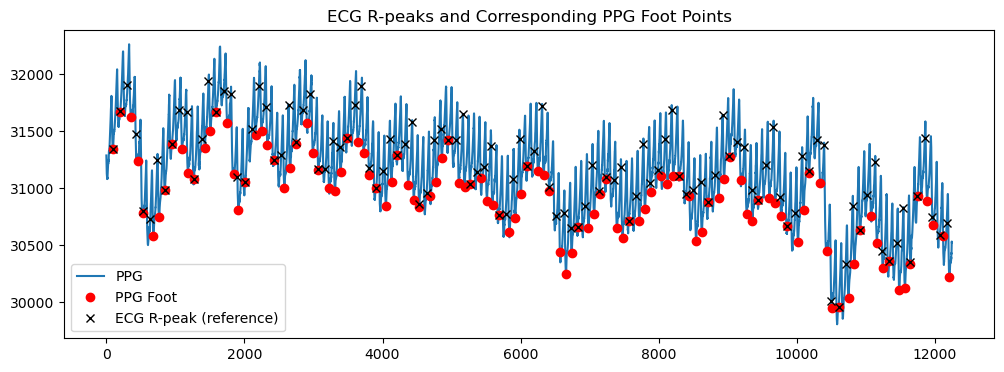

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(ppg, label="PPG")
plt.plot(ppg_foot_indices, ppg[ppg_foot_indices], "ro", label="PPG Foot")
plt.plot(peaks, ppg[peaks], "kx", label="ECG R-peak (reference)")
plt.legend()
plt.title("ECG R-peaks and Corresponding PPG Foot Points")
plt.show()
